# Notebook 24 — Wu 2003 SBI Training: S-B Structure

Train a Neural Posterior Estimator (SNPE-C / NPE) on the **S-B** observation structure
(no distillate-composition analyser).

**Contents:**
1. Generate training data by prior sampling + simulation
2. Train SNPE with a Neural Spline Flow density estimator
3. Simulation-Based Calibration (SBC)
4. Snapshot posteriors for key scenarios
5. W12 corner plot — banana-shaped posterior (alpha/eta_col degeneracy)
6. Save posterior
7. Marginal posteriors across all 16 scenarios

**Runtime notes:**
- Data generation with `N_TRAIN=1000`: ~5–15 min on CPU
- SNPE training (200 epochs max): ~5–20 min
- Set `N_TRAIN=3000` for publication quality

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import time
import pathlib

from cstr_sbi.recycle.priors import box_uniform_5d, PRIOR_LOW_5D, PRIOR_HIGH_5D
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, NOMINAL_Y0_EXPLICIT, PARAM_NAMES,
    simulate_trajectory_explicit_jit, extract_observations_explicit
)
from cstr_sbi.recycle.summaries import compute_summaries, N_SUMMARIES_SB
from cstr_sbi.recycle.scenarios import CLOSED_LOOP_NAMES, get_scenario, list_closed_loop
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window

import jax.numpy as jnp
import jax

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs'); SBI_LOGS.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print(f"torch: {torch.__version__}")
print(f"N_SUMMARIES_SB={N_SUMMARIES_SB}, PARAM_NAMES={PARAM_NAMES}")

torch: 2.12.0
N_SUMMARIES_SB=66, PARAM_NAMES=['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']


## 1. Generate Training Data via Prior Sampling

For each theta drawn from the prior we:
1. Simulate a 2 h window with `simulate_trajectory_explicit`
2. Extract the 12-channel raw observation via `extract_observations_explicit`
3. Add 0.3% white noise
4. Compute the 66-D S-B summary vector

Simulations that produce NaN (numerical instability near prior boundaries) are discarded.

In [2]:
# rtol=1e-3, atol=1e-5: loose tolerances for SBI training data.
# Tight tolerances (1e-6/1e-8) cause 100-200s per sim for extreme prior samples
# (near-stiff dynamics). Loose tolerances give ~0.5s per sim with negligible
# impact on summary statistics quality for SBI purposes.
N_TRAIN = 15000
print(f"Generating {N_TRAIN} S-B training simulations (rtol=1e-3, atol=1e-5)...")
print("Expected time: ~2-3h on CPU.")

prior = box_uniform_5d()
rng_np = np.random.default_rng(20260625)
y0_sb = nominal_warm_start("S-B")

thetas_list = []
summaries_list = []
t0 = time.time()

theta_samples = prior.sample((N_TRAIN,)).numpy()

for i, th in enumerate(theta_samples):
    theta_jnp = jnp.array(th, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(
        theta_jnp, NOMINAL_INLET, NOMINAL_CTRL_SB, y0_sb,
        t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5
    )
    raw = extract_observations_explicit(ys, theta_jnp, NOMINAL_CTRL_SB)
    raw_np = np.asarray(raw)
    t_np = np.asarray(ts)
    if np.isnan(raw_np).any() or np.isinf(raw_np).any():
        continue
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_np.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", t_np)
    if np.isnan(s).any():
        continue
    thetas_list.append(th)
    summaries_list.append(s)
    if (i + 1) % 500 == 0:
        elapsed = time.time() - t0
        print(f"  {i+1}/{N_TRAIN}  ({elapsed:.0f}s elapsed, {len(thetas_list)} valid)")

thetas_arr = np.stack(thetas_list)
summaries_arr = np.stack(summaries_list)
print(f"\nValid simulations: {len(thetas_arr)}/{N_TRAIN}")
print(f"thetas shape:    {thetas_arr.shape}")
print(f"summaries shape: {summaries_arr.shape}")
np.savez(DATA / 'wu2003_sbi_train_sb.npz', thetas=thetas_arr, summaries=summaries_arr)
print(f"Saved training data to {DATA / 'wu2003_sbi_train_sb.npz'}")

Generating 15000 S-B training simulations (rtol=1e-3, atol=1e-5)...
Expected time: ~2-3h on CPU.


  500/15000  (52s elapsed, 500 valid)


  1000/15000  (103s elapsed, 1000 valid)


  1500/15000  (157s elapsed, 1500 valid)


  2000/15000  (211s elapsed, 2000 valid)


...

  13000/15000  (1475s elapsed, 13000 valid)


  13500/15000  (1534s elapsed, 13500 valid)


  14000/15000  (1590s elapsed, 14000 valid)


  14500/15000  (1649s elapsed, 14500 valid)


  15000/15000  (1708s elapsed, 15000 valid)

Valid simulations: 15000/15000
thetas shape:    (15000, 5)
summaries shape: (15000, 66)
Saved training data to ../data/wu2003_sbi_train_sb.npz


## 2. Train SNPE-C (Neural Spline Flow)

In [3]:
from sbi.inference import SNPE
from sbi.neural_nets import posterior_nn  # sbi >= 0.23: moved from sbi.utils

# Load training data — allows re-running this cell independently after data gen
train_data = np.load(DATA / 'wu2003_sbi_train_sb.npz')
thetas_t = torch.tensor(train_data['thetas'], dtype=torch.float32)
summaries_t = torch.tensor(train_data['summaries'], dtype=torch.float32)
print(f"Training data: {thetas_t.shape[0]} samples, {summaries_t.shape[1]}-D summaries")

prior = box_uniform_5d()

# Neural Spline Flow (NSF) density estimator
density_estimator = posterior_nn(
    model='nsf',
    hidden_features=128,
    num_transforms=5,
)

inference = SNPE(prior=prior, density_estimator=density_estimator)
inference.append_simulations(thetas_t, summaries_t)

print("Training SNPE (up to 200 epochs, early stopping at 20 epochs without improvement)...")
print("Expected time: ~5–20 min")
t0 = time.time()
density_estimator_trained = inference.train(
    max_num_epochs=200,
    validation_fraction=0.1,
    stop_after_epochs=20,
    show_train_summary=True,
)
elapsed = time.time() - t0
print(f"\nTraining completed in {elapsed:.0f}s")

Training data: 15000 samples, 66-D summaries
Training SNPE (up to 200 epochs, early stopping at 20 epochs without improvement)...
Expected time: ~5–20 min


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 31, 49, 50, 51, 52, 53, 54, 61] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Training neural network. Epochs trained: 1

 Training neural network. Epochs trained: 2

 Training neural network. Epochs trained: 3

...

 Training neural network. Epochs trained: 125

 Training neural network. Epochs trained: 126

 Training neural network. Epochs trained: 127

 Training neural network. Epochs trained: 128

 Neural network successfully converged after 129 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 129
        Best validation performance: -18.7466
        -------------------------
        

Training completed in 155s


In [4]:
posterior_sb = inference.build_posterior(density_estimator_trained)
print(f"S-B posterior built: {type(posterior_sb)}")

S-B posterior built: <class 'sbi.inference.posteriors.direct_posterior.DirectPosterior'>


## 3. Simulation-Based Calibration (SBC)

For each of `N_SBC` prior samples we simulate a synthetic observation, draw `N_POST`
posterior samples and compute the rank of the true theta in each marginal.
Uniform rank histograms indicate a well-calibrated posterior.

In [5]:
N_SBC = 200   # 500 for publication
N_POST = 100  # posterior samples per SBC trial
print(f"Running SBC: {N_SBC} prior samples, {N_POST} posterior samples each...")

sbc_thetas = prior.sample((N_SBC,)).numpy()
sbc_ranks = np.zeros((N_SBC, 5), dtype=int)
rng_sbc = np.random.default_rng(999)
t0 = time.time()

for i, th in enumerate(sbc_thetas):
    theta_jnp = jnp.array(th, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(
        theta_jnp, NOMINAL_INLET, NOMINAL_CTRL_SB, y0_sb,
        t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5
    )
    raw = extract_observations_explicit(ys, theta_jnp, NOMINAL_CTRL_SB)
    raw_np = np.asarray(raw)
    t_np = np.asarray(ts)
    if np.isnan(raw_np).any() or np.isinf(raw_np).any():
        sbc_ranks[i] = N_POST // 2  # neutral rank for failed sims
        continue
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_sbc.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", t_np)
    if np.isnan(s).any():
        sbc_ranks[i] = N_POST // 2
        continue
    x_obs = torch.tensor(s, dtype=torch.float32)
    post_samples = posterior_sb.sample((N_POST,), x=x_obs).numpy()
    for k in range(5):
        sbc_ranks[i, k] = int(np.sum(post_samples[:, k] < th[k]))
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N_SBC}  ({time.time()-t0:.0f}s)")

print(f"SBC completed in {time.time()-t0:.0f}s")

Running SBC: 200 prior samples, 100 posterior samples each...


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2279.)
  outputs, _ = torch.triangular_solve(


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  200/200  (29s)
SBC completed in 29s


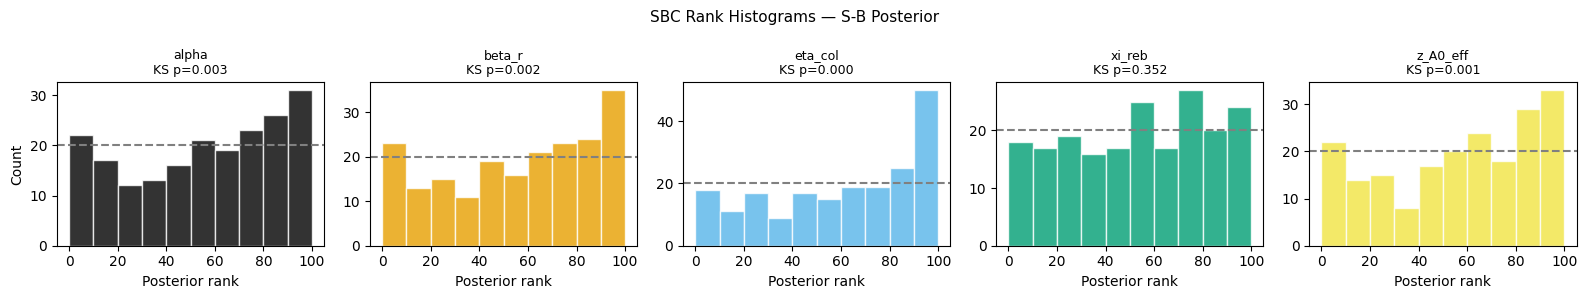

Saved nb24_sbc_ranks_sb.png


In [6]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
n_bins = 10
uniform_count = N_SBC / n_bins
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.hist(sbc_ranks[:, k], bins=n_bins, range=(0, N_POST),
            color=OI[k % len(OI)], edgecolor='white', alpha=0.8)
    ax.axhline(uniform_count, ls='--', color='gray', lw=1.5, label='Uniform')
    ks_p = scipy_stats.ks_1samp(
        sbc_ranks[:, k] / N_POST, scipy_stats.uniform.cdf
    ).pvalue
    ax.set_title(f"{param}\nKS p={ks_p:.3f}", fontsize=9)
    ax.set_xlabel("Posterior rank")
    if k == 0:
        ax.set_ylabel("Count")
plt.suptitle("SBC Rank Histograms — S-B Posterior", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'nb24_sbc_ranks_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb24_sbc_ranks_sb.png")

## 4. Snapshot Posteriors for Key Scenarios

In [7]:
spotlight_scenarios = [
    "W1_healthy", "W3_cat_severe", "W6_jacket_severe",
    "W9_reb_fouling", "W12_snowball_compound", "W15_snowball_threshold"
]

snapshot_samples = {}
for sc_name in spotlight_scenarios:
    sc = get_scenario(sc_name)
    t_h_s, raw_det = deterministic_window(sc, structure="S-B", y0=y0_sb)
    raw_np = np.asarray(raw_det)
    rng_snap = np.random.default_rng(42)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_snap.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", np.asarray(t_h_s))
    x_obs = torch.tensor(s, dtype=torch.float32)
    samples = posterior_sb.sample((2000,), x=x_obs).numpy()
    snapshot_samples[sc_name] = samples
    true_th = np.asarray(sc.theta())
    print(
        f"{sc_name}: true alpha={true_th[0]:.2f}, "
        f"post_mean_alpha={samples[:, 0].mean():.3f} "
        f"(90% CI [{np.percentile(samples[:,0],5):.3f}, {np.percentile(samples[:,0],95):.3f}])"
    )

  0%|          | 0/2000 [00:00<?, ?it/s]

W1_healthy: true alpha=1.00, post_mean_alpha=0.871 (90% CI [0.782, 1.022])


  0%|          | 0/2000 [00:00<?, ?it/s]

W3_cat_severe: true alpha=0.65, post_mean_alpha=0.560 (90% CI [0.468, 0.676])


  0%|          | 0/2000 [00:00<?, ?it/s]

...

W9_reb_fouling: true alpha=1.00, post_mean_alpha=0.887 (90% CI [0.783, 1.034])


  0%|          | 0/2000 [00:00<?, ?it/s]

W12_snowball_compound: true alpha=0.75, post_mean_alpha=0.655 (90% CI [0.548, 0.786])


  0%|          | 0/2000 [00:00<?, ?it/s]

W15_snowball_threshold: true alpha=0.58, post_mean_alpha=0.500 (90% CI [0.423, 0.599])


## 5. W12 Corner Plot — Banana Posterior (alpha/eta_col Degeneracy)

W12 (`alpha=0.75`, `eta_col=0.80`) is the key scenario where both parameters
are degraded simultaneously.  Under S-B the two effects on F_R are nearly indistinguishable,
producing the characteristic banana-shaped joint marginal.

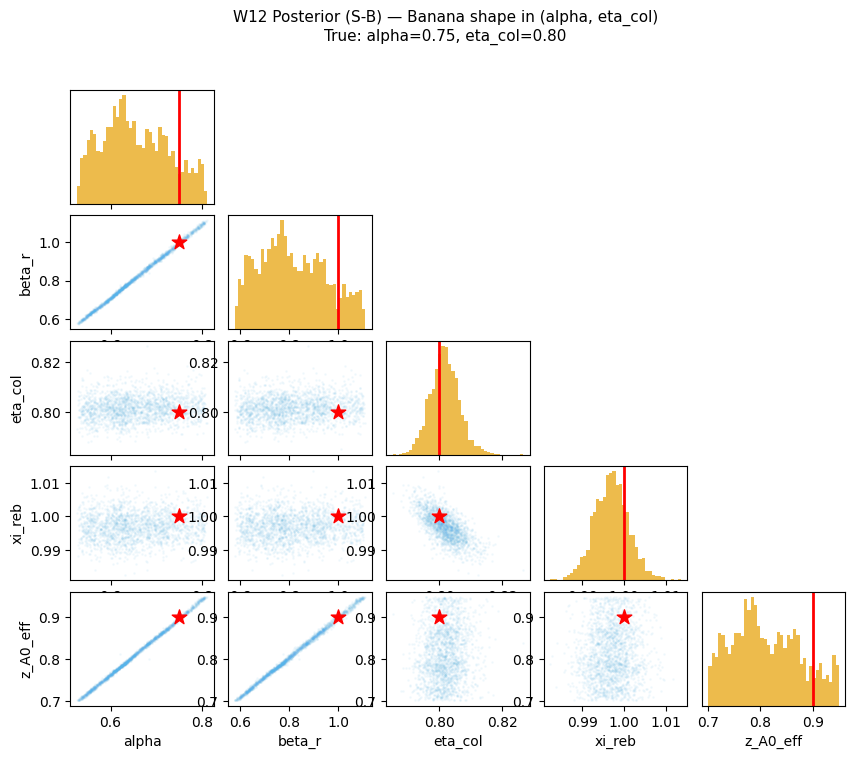

Saved nb24_w12_posterior_sb.png


In [8]:
try:
    from matplotlib.gridspec import GridSpec

    sc_name = "W12_snowball_compound"
    sc = get_scenario(sc_name)
    true_th = np.asarray(sc.theta())
    samp = snapshot_samples[sc_name]

    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(5, 5, figure=fig, hspace=0.1, wspace=0.1)

    for i in range(5):
        for j in range(5):
            ax = fig.add_subplot(gs[i, j])
            if i == j:
                ax.hist(samp[:, i], bins=40, color=OI[1], alpha=0.7, density=True)
                ax.axvline(true_th[i], color='red', lw=2)
                ax.set_xlabel(PARAM_NAMES[i] if i == 4 else "")
                ax.set_yticks([])
            elif i > j:
                ax.scatter(samp[:, j], samp[:, i], alpha=0.05, s=1, color=OI[2])
                ax.scatter(true_th[j], true_th[i], color='red', marker='*',
                           s=120, zorder=5)
                ax.set_xlabel(PARAM_NAMES[j] if i == 4 else "")
                ax.set_ylabel(PARAM_NAMES[i] if j == 0 else "")
            else:
                ax.set_visible(False)

    plt.suptitle(
        f"W12 Posterior (S-B) — Banana shape in (alpha, eta_col)\n"
        f"True: alpha={true_th[0]:.2f}, eta_col={true_th[2]:.2f}",
        fontsize=11
    )
    plt.savefig(FIGURES / 'nb24_w12_posterior_sb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved nb24_w12_posterior_sb.png")
except Exception as e:
    print(f"Corner plot failed: {e}")

## 6. Save Posterior

In [9]:
save_path = SBI_LOGS / 'wu2003_posterior_sb.pkl'
with open(save_path, 'wb') as f:
    pickle.dump({
        'posterior': posterior_sb,
        'inference': inference,
        'density_estimator': density_estimator_trained,
        'N_TRAIN': len(thetas_arr),
    }, f)
print(f"Posterior saved to {save_path}")

Posterior saved to ../sbi-logs/wu2003_posterior_sb.pkl


/var/folders/pk/y59h45m94tq3dzsk9n26k2kc0000gp/T/ipykernel_45470/2560559075.py:3: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump({


## 7. Marginal Posteriors Across All 16 Scenarios

For each scenario: simulate a deterministic window, add noise, draw 500 posterior samples.
Plot posterior mean ± 90% CI vs true parameter value.

Sampling posteriors for all 14 scenarios...


  0%|          | 0/500 [00:00<?, ?it/s]

  W1_healthy: alpha true=1.00, mean=0.896


  0%|          | 0/500 [00:00<?, ?it/s]

  W2_cat_mild: alpha true=0.85, mean=0.778


...

  W13_cat_feed: alpha true=0.80, mean=0.776


  0%|          | 0/500 [00:00<?, ?it/s]

  W15_snowball_threshold: alpha true=0.58, mean=0.517


  0%|          | 0/500 [00:00<?, ?it/s]

  W16_full_multi: alpha true=0.75, mean=0.688


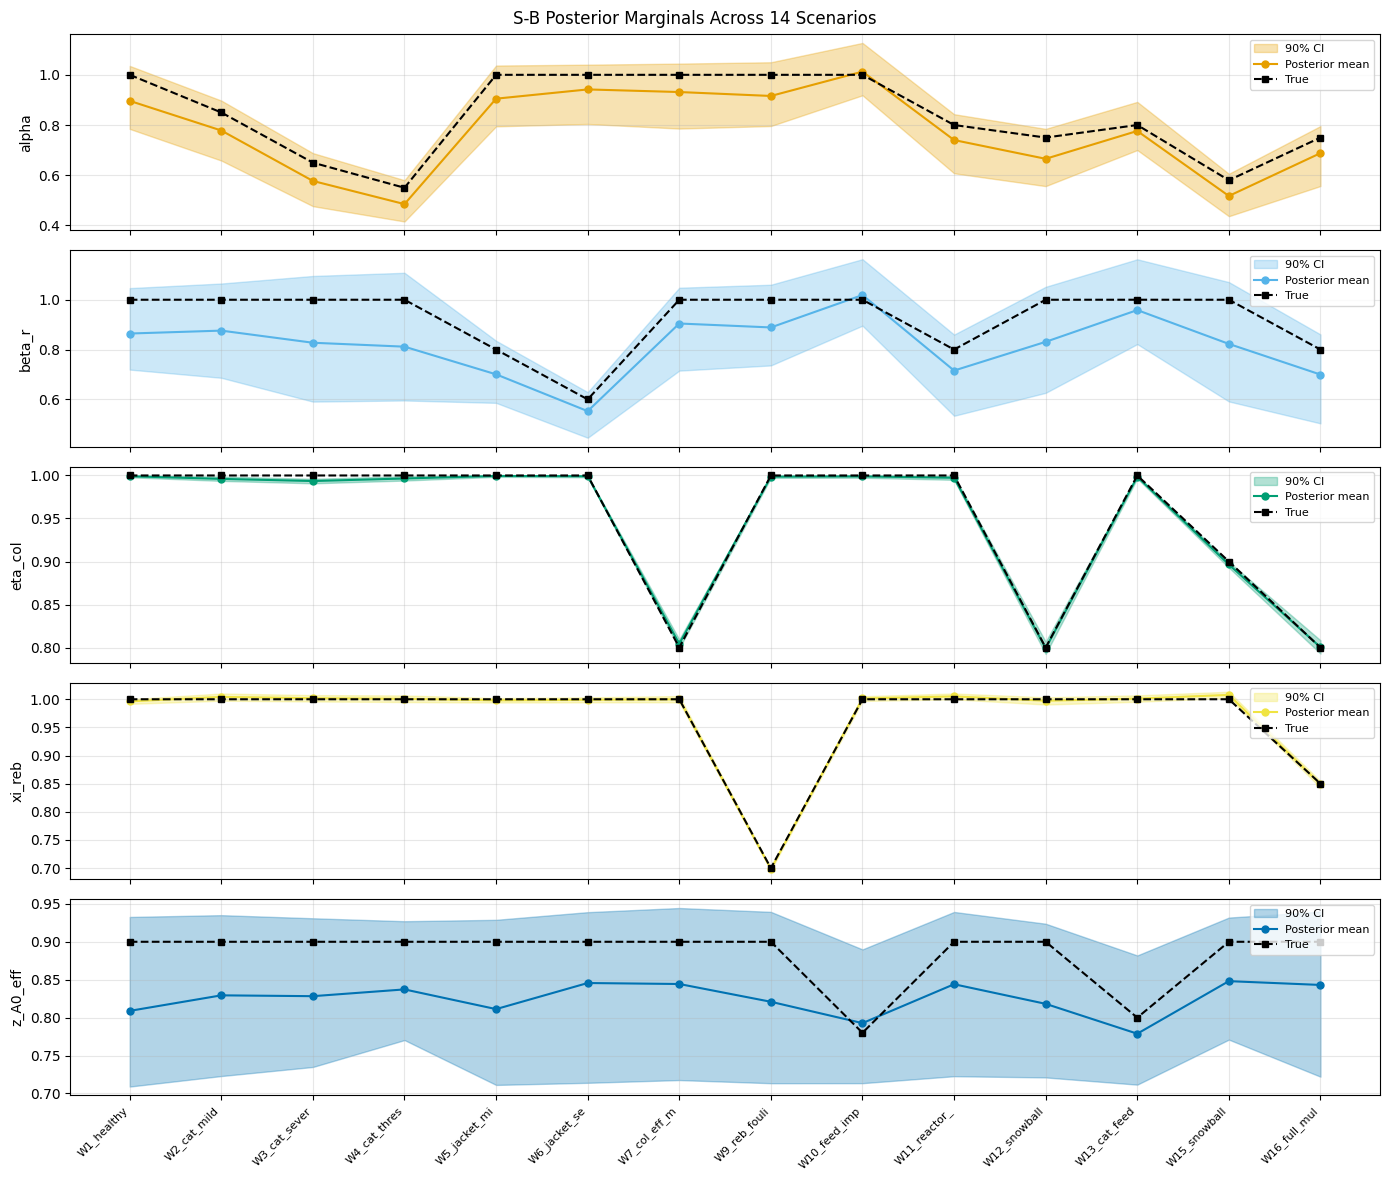

Saved nb24_marginal_posteriors_sb.png

=== Notebook 24 complete ===


In [10]:
print(f"Sampling posteriors for all {len(CLOSED_LOOP_NAMES)} scenarios...")
n_sc = len(CLOSED_LOOP_NAMES)
param_means = np.zeros((n_sc, 5))
param_lo90  = np.zeros((n_sc, 5))
param_hi90  = np.zeros((n_sc, 5))
param_true  = np.zeros((n_sc, 5))

for i, sc_name in enumerate(CLOSED_LOOP_NAMES):
    sc = get_scenario(sc_name)
    t_h_s, raw_det = deterministic_window(sc, structure="S-B", y0=y0_sb)
    raw_np = np.asarray(raw_det)
    rng_m = np.random.default_rng(i + 100)
    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_m.normal(0, 0.003 * scale, raw_np.shape)
    s = compute_summaries(raw_np + noise, "S-B", np.asarray(t_h_s))
    x_obs = torch.tensor(s, dtype=torch.float32)
    samp = posterior_sb.sample((500,), x=x_obs).numpy()
    param_means[i] = samp.mean(axis=0)
    param_lo90[i]  = np.percentile(samp, 5,  axis=0)
    param_hi90[i]  = np.percentile(samp, 95, axis=0)
    param_true[i]  = np.asarray(sc.theta())
    print(f"  {sc_name}: alpha true={param_true[i,0]:.2f}, mean={param_means[i,0]:.3f}")

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
x_pos = np.arange(n_sc)
for k, (ax, param) in enumerate(zip(axes, PARAM_NAMES)):
    ax.fill_between(x_pos, param_lo90[:, k], param_hi90[:, k],
                    alpha=0.3, color=OI[(k + 1) % len(OI)], label='90% CI')
    ax.plot(x_pos, param_means[:, k], 'o-', color=OI[(k + 1) % len(OI)],
            label='Posterior mean', ms=5, lw=1.5)
    ax.plot(x_pos, param_true[:, k],  's--', color='black',
            label='True', ms=5, lw=1.5)
    ax.set_ylabel(param, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels([n[:12] for n in CLOSED_LOOP_NAMES],
                          rotation=45, ha='right', fontsize=8)
plt.suptitle(f"S-B Posterior Marginals Across {n_sc} Scenarios", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb24_marginal_posteriors_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb24_marginal_posteriors_sb.png")
print()
print("=== Notebook 24 complete ===")